# 13 · Bistability probe — does the model have multiple attractors?

**Why this notebook.** `notebooks/12_resource_coupling_gating.ipynb` (the
Tier-A multi-seed gate) failed 3/4. The smoking gun: Runs B and D
(trust-frozen ablation) produce *identical* trajectories. Combined with
the §4.5 falsifier failure (cost-r-independent Run C still produces a
loop area of 0.69 vs B's 0.77), the implication is that the "hysteresis"
in nb12 is **not a bistability-induced loop** but the slow lag of $\bar\mu$
chasing a forced $\theta^*(t)$ schedule. See
[[project_gating_notebook12]] for the full diagnosis.

This is the cheapest possible test of the alternative hypothesis: at
**fixed** $\theta^* = 1$ (no reversal, no shock — just the relativistic
truth held constant), does the model have multiple stable fixed
points in belief space? The Strogatz test:

| Initial condition | Description | Predicted behaviour |
|---|---|---|
| $\mu_{\rm init} = 0$ | Entrenched Newtonian | If monostable → reaches 1; if bistable → stays near 0 |
| $\mu_{\rm init} = 1$ | Already correct | Stays near 1 in both cases |

If both ICs converge to the same equilibrium, no bistability exists,
and the paper's headline mechanism ("paradigm capture" as a path-
dependent transition between attractors) has no dynamical-systems
basis. Paths I, II, III from
`~/.claude/plans/wiggly-munching-garden.md` then all face the same
structural wall, and the model needs to be rebuilt around an explicit
bistability mechanism (e.g. a multimodal posterior).

**The phase-diagram-style probe.** We also vary $R_{\rm in}$ to ask
whether bistability *appears* in the low-resource regime — i.e. whether
the cost barrier produces a low-$r$ trapped basin even though the
high-$r$ regime is monostable.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from dataclasses import replace

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import equinox as eqx
import seaborn as sns

from src import (
    ModelConfig, NetworkConfig, PolicyConfig, ResourceConfig,
    TrustConfig, InferenceConfig, UtilityConfig, WorldConfig,
)
from src.network import build_adjacency
from src.population import Population
from src import resource as resmod
from src import observables as obs

sns.set_theme(context='notebook', style='whitegrid')
print('imports ok')


imports ok


## §1 · Setup

Small uniform population (N=20) on a Watts-Strogatz graph — bistability
is a *dynamical-systems* property, not a network-topology property, so
we drop the SBM here to isolate the question. Fixed $\theta^* = 1$ via
`schedule='step'` with `theta_star_pre = theta_star_post = 1.0`.

Equilibration time T_EQ=400 (≈ 4× the time-to-shift seen in nb12, so
the system should be deeply in its attractor by the end).


In [2]:
N = 20
T_EQ = 400
N_SEEDS = 5

def make_cfg(R_in: float, c0: float = 0.01, seed: int = 0) -> ModelConfig:
    """Fixed θ*=1 throughout the run; otherwise nb12's working calibration."""
    return ModelConfig(
        n_agents=N, seed=seed,
        mu_0=0.0, tau_0=1.0,                  # overridden per-IC below
        world=WorldConfig(
            schedule='step',
            schedule_t_shift=0,                # shift at t=0 ⇒ θ*=post for all t≥0
            theta_star_pre=1.0,                # but pre=post=1 so no actual shift
            theta_star_post=1.0,
        ),
        policy=PolicyConfig(
            objective='resource_gain',
            x_grid=(0.3, 1.0, 2.0, 3.0),
            beta_exp=2.0,
        ),
        inference=InferenceConfig(posterior_rho=1.0),
        trust=TrustConfig(rho=0.99, prior_n0=1.0, prior_eps0=1.0, learning=True),
        network=NetworkConfig(kind='watts_strogatz', mean_degree=4, rewiring_p=0.1),
        resource=ResourceConfig(
            R_in=R_in, alpha_flow=0.15, delta_decay=0.02,
            r0=3.0, c0=c0, r_min=0.0,
            fisher_cost_steepness=1.0, barrier_eps=1e-3,
        ),
        utility=UtilityConfig(lambda_mc=0.0),
    )


def build_with_mu_init(cfg: ModelConfig, mu_init: float,
                       tau_init: float = 1.0) -> Population:
    """Build via factory; override (mu, tau) to a uniform initial condition."""
    pop = Population.init(cfg, jax.random.PRNGKey(cfg.seed))
    mu = jnp.full((N,), mu_init)
    tau = jnp.full((N,), tau_init)
    return eqx.tree_at(lambda p: (p.mu, p.tau), pop, (mu, tau))


def run_to_eq(cfg: ModelConfig, mu_init: float,
              tau_init: float = 1.0) -> dict:
    """Run T_EQ steps from a planted initial condition; return the
    trajectory + terminal state."""
    pop = build_with_mu_init(cfg, mu_init, tau_init)
    mu_t = np.zeros(T_EQ)
    r_t = np.zeros(T_EQ)
    for t in range(T_EQ):
        pop, _ = pop.step(t)
        mu_t[t] = float(pop.mu.mean())
        r_t[t] = float(pop.r.mean())
    return dict(
        mu_t=mu_t,
        r_t=r_t,
        mu_final=float(pop.mu.mean()),
        mu_final_std=float(pop.mu.std()),
        r_final=float(pop.r.mean()),
        gamma_final=np.asarray(pop.gamma),
        seed=cfg.seed, R_in=cfg.resource.R_in, mu_init=mu_init,
    )


## §2 · Test 1 — Two-IC trajectory test

For each of three $R_{\rm in}$ values (low / medium / high), run from
$\mu_{\rm init} \in \{0, 1\}$ for $N_{\rm SEEDS}$ seeds each. Plot
trajectories.

The single qualitative read: at $t = T_{\rm EQ}$, do the two ICs land at
the same $\bar\mu$?


In [3]:
R_in_values = [0.5, 3.0, 10.0]   # low (cost-pinned), medium, high
mu_init_values = [0.0, 1.0]

# Run grid: (R_in, mu_init, seed)
trajectories = {}  # keyed by (R_in, mu_init)
for R_in in R_in_values:
    for mu_init in mu_init_values:
        runs = [run_to_eq(make_cfg(R_in, seed=s), mu_init) for s in range(N_SEEDS)]
        trajectories[(R_in, mu_init)] = runs
        finals = [r['mu_final'] for r in runs]
        print(f'R_in={R_in:4.1f}  mu_init={mu_init}  '
              f'mu_final mean={np.mean(finals):+.4f}  '
              f'std across seeds={np.std(finals):.4f}')


R_in= 0.5  mu_init=0.0  mu_final mean=+1.0017  std across seeds=0.0113


R_in= 0.5  mu_init=1.0  mu_final mean=+1.0067  std across seeds=0.0104


R_in= 3.0  mu_init=0.0  mu_final mean=+1.0012  std across seeds=0.0020


R_in= 3.0  mu_init=1.0  mu_final mean=+1.0013  std across seeds=0.0021


R_in=10.0  mu_init=0.0  mu_final mean=+1.0009  std across seeds=0.0009


R_in=10.0  mu_init=1.0  mu_final mean=+1.0009  std across seeds=0.0009


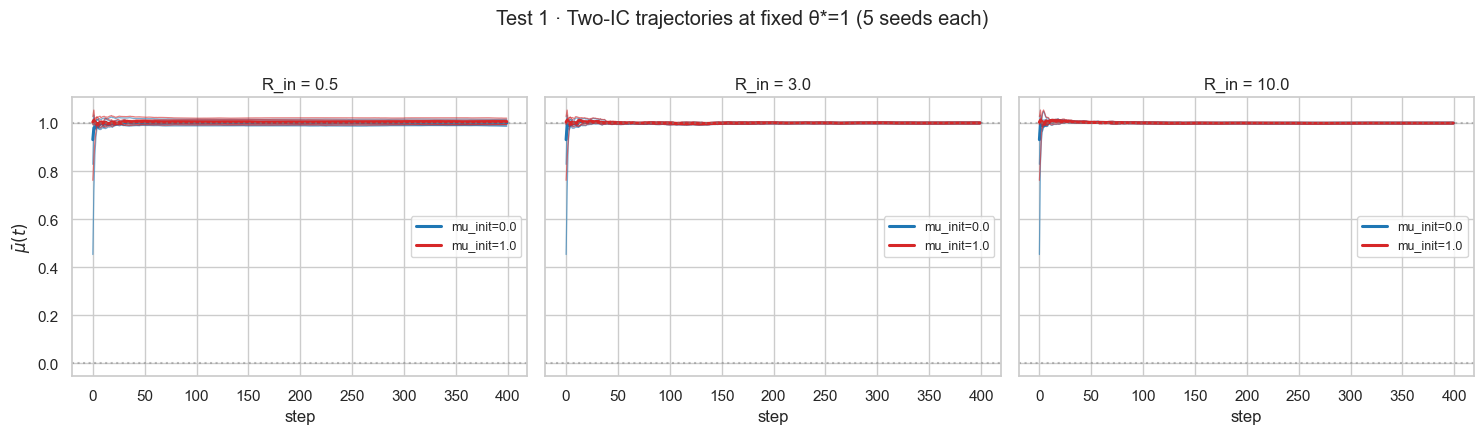

In [4]:
# Plot trajectories side by side per R_in.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)

for ax, R_in in zip(axes, R_in_values):
    for mu_init, color in zip(mu_init_values, ['#1f77b4', '#d62728']):
        for run in trajectories[(R_in, mu_init)]:
            ax.plot(run['mu_t'], color=color, lw=0.9, alpha=0.6)
        # Median trajectory in thick.
        med = np.median(np.stack([r['mu_t'] for r in trajectories[(R_in, mu_init)]]), axis=0)
        ax.plot(med, color=color, lw=2.2, label=f'mu_init={mu_init}')
    ax.axhline(1.0, color='gray', ls=':', alpha=0.5)
    ax.axhline(0.0, color='gray', ls=':', alpha=0.5)
    ax.set(xlabel='step', title=f'R_in = {R_in}')
    ax.legend(loc='best', fontsize=9)
axes[0].set_ylabel(r'$\bar\mu(t)$')
fig.suptitle('Test 1 · Two-IC trajectories at fixed θ*=1 (5 seeds each)', y=1.03)
plt.tight_layout()
plt.show()


## §3 · Test 2 — Basin map

Sweep $\mu_{\rm init}$ over a finer grid and report the terminal $\bar\mu$
for each. A monostable system gives a near-flat line (all ICs collapse to
the attractor). A bistable system gives a step. Repeat for each $R_{\rm in}$.


In [5]:
mu_init_grid = np.linspace(-0.5, 1.5, 11)
N_SEEDS_BASIN = 3   # smaller; mu_init grid × R_in grid × seeds = 33 × 3 = 99 runs

basin = {R_in: {} for R_in in R_in_values}
for R_in in R_in_values:
    for mu_init in mu_init_grid:
        finals = []
        for s in range(N_SEEDS_BASIN):
            res = run_to_eq(make_cfg(R_in, seed=s), float(mu_init))
            finals.append(res['mu_final'])
        basin[R_in][float(mu_init)] = finals
    print(f'  done basin R_in={R_in}')


  done basin R_in=0.5


  done basin R_in=3.0


  done basin R_in=10.0


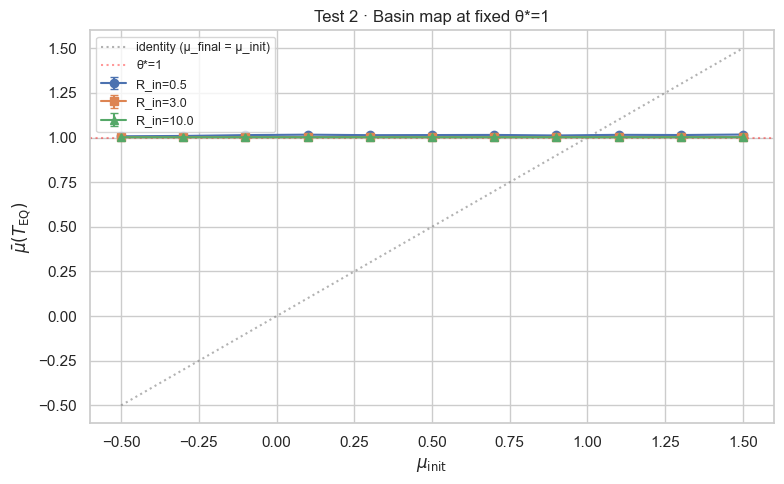

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
markers = ['o', 's', '^']
for R_in, m in zip(R_in_values, markers):
    xs = sorted(basin[R_in].keys())
    medians = [np.median(basin[R_in][x]) for x in xs]
    mins = [np.min(basin[R_in][x]) for x in xs]
    maxs = [np.max(basin[R_in][x]) for x in xs]
    ax.errorbar(xs, medians,
                yerr=[np.array(medians)-np.array(mins),
                      np.array(maxs)-np.array(medians)],
                marker=m, lw=1.5, label=f'R_in={R_in}', capsize=3, capthick=1)
ax.plot([min(mu_init_grid), max(mu_init_grid)],
        [min(mu_init_grid), max(mu_init_grid)],
        ls=':', color='gray', alpha=0.6, label='identity (μ_final = μ_init)')
ax.axhline(1.0, color='red', ls=':', alpha=0.4, label='θ*=1')
ax.set(xlabel=r'$\mu_{\rm init}$', ylabel=r'$\bar\mu(T_{\rm EQ})$',
       title='Test 2 · Basin map at fixed θ*=1')
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()


## §4 · Test 3 — Resource and trust at the two ICs

Even if μ collapses to one attractor, the resource and trust distributions
might bifurcate. Plot final $\bar r$ and $\|\Gamma_{\rm IC=0}-\Gamma_{\rm IC=1}\|_F$
per seed.


In [7]:
# For each R_in, compare the (r_final, gamma_final) of the two ICs.
print('Resource and trust comparison at T_EQ:')
print('-' * 70)
for R_in in R_in_values:
    runs_0 = trajectories[(R_in, 0.0)]
    runs_1 = trajectories[(R_in, 1.0)]
    r_0 = np.array([r['r_final'] for r in runs_0])
    r_1 = np.array([r['r_final'] for r in runs_1])
    gamma_dist = [
        float(np.linalg.norm(g0['gamma_final'] - g1['gamma_final'], ord='fro'))
        for g0, g1 in zip(runs_0, runs_1)
    ]
    print(f'R_in={R_in:4.1f}')
    print(f'  r_final: IC=0 → {r_0.mean():+.3f}±{r_0.std():.3f}   '
          f'IC=1 → {r_1.mean():+.3f}±{r_1.std():.3f}   '
          f'gap = {r_1.mean() - r_0.mean():+.3f}')
    print(f'  ‖Γ(IC=0) − Γ(IC=1)‖_F (per seed): '
          f'mean={np.mean(gamma_dist):.4f}  max={np.max(gamma_dist):.4f}')
print()


Resource and trust comparison at T_EQ:
----------------------------------------------------------------------
R_in= 0.5
  r_final: IC=0 → -0.103±0.030   IC=1 → -0.076±0.021   gap = +0.028
  ‖Γ(IC=0) − Γ(IC=1)‖_F (per seed): mean=0.0001  max=0.0001
R_in= 3.0
  r_final: IC=0 → +4.399±0.358   IC=1 → +4.406±0.365   gap = +0.007
  ‖Γ(IC=0) − Γ(IC=1)‖_F (per seed): mean=0.0001  max=0.0002
R_in=10.0
  r_final: IC=0 → +22.074±0.110   IC=1 → +22.074±0.110   gap = +0.000
  ‖Γ(IC=0) − Γ(IC=1)‖_F (per seed): mean=0.0001  max=0.0001



## §5 · Verdict

Three possible outcomes, each with concrete consequences.


In [8]:
# Compute the verdict for each R_in.
print('=' * 70)
print('BISTABILITY VERDICT')
print('=' * 70)

verdicts = {}
for R_in in R_in_values:
    finals_0 = np.array([r['mu_final'] for r in trajectories[(R_in, 0.0)]])
    finals_1 = np.array([r['mu_final'] for r in trajectories[(R_in, 1.0)]])
    gap = abs(finals_1.mean() - finals_0.mean())
    within_seed_spread = max(finals_0.std(), finals_1.std())
    # Bistable if the across-IC gap is much larger than within-IC seed noise
    # AND the gap is non-trivial (> 0.2 say).
    if gap > 0.2 and gap > 5 * within_seed_spread:
        verdict = 'BISTABLE'
    elif gap < 0.05:
        verdict = 'MONOSTABLE'
    else:
        verdict = 'MARGINAL'
    verdicts[R_in] = (verdict, gap, finals_0.mean(), finals_1.mean())
    print(f'R_in = {R_in:4.1f}:  {verdict}')
    print(f'    μ_eq(IC=0) = {finals_0.mean():+.4f} ± {finals_0.std():.4f}')
    print(f'    μ_eq(IC=1) = {finals_1.mean():+.4f} ± {finals_1.std():.4f}')
    print(f'    gap        = {gap:.4f}')
    print()

print('=' * 70)
print('Interpretation')
print('=' * 70)
all_mono = all(v[0] == 'MONOSTABLE' for v in verdicts.values())
all_bi = all(v[0] == 'BISTABLE' for v in verdicts.values())
any_bi = any(v[0] == 'BISTABLE' for v in verdicts.values())

if all_mono:
    print('MONOSTABLE across all R_in tested.')
    print('Implication: the model has a single attractor at fixed θ*. The')
    print('hysteresis loops in nb12 were slow tracking of forced θ*(t), not')
    print('bistability-induced. Path II (Tier-B repair) cannot produce')
    print('genuine paradigm capture without a structural mechanism change')
    print('(e.g. multimodal posterior, explicit attractor switching).')
elif all_bi:
    print('BISTABLE across all R_in tested.')
    print('Implication: the model has multiple attractors. The nb12 gate')
    print('failed not because bistability is absent, but because the symmetric')
    print('init landed on one specific basin. Path II (Tier-B repair) is')
    print('promising — need to redesign nb12 to plant ICs in *different*')
    print('basins per community.')
elif any_bi:
    print('R_IN-MODULATED BISTABILITY.')
    print(f'Bistable at R_in ∈ ' +
          str([R for R, (v,_,_,_) in verdicts.items() if v == "BISTABLE"]))
    print(f'Monostable at R_in ∈ ' +
          str([R for R, (v,_,_,_) in verdicts.items() if v == "MONOSTABLE"]))
    print('Implication: resource gates the basin structure. This is the')
    print('most interesting outcome — it would put resource on the')
    print('dynamical-systems map. Path II is promising; the gate notebook')
    print('needs to operate in the bistable regime to see paradigm capture.')
else:
    print('MARGINAL across all R_in tested.')
    print('Implication: equilibration is slow / borderline. May need longer')
    print('T_EQ, finer μ_init grid near the suspected boundary, or a')
    print('different ablation to disambiguate slow tracking from')
    print('near-bistable dynamics.')

VERDICT = {
    'per_R_in': {f'R_in={R}': v[0] for R, v in verdicts.items()},
    'global': ('MONOSTABLE' if all_mono else
               'BISTABLE' if all_bi else
               'R_IN_MODULATED' if any_bi else
               'MARGINAL'),
    'gaps': {f'R_in={R}': float(v[1]) for R, v in verdicts.items()},
}
VERDICT


BISTABILITY VERDICT
R_in =  0.5:  MONOSTABLE
    μ_eq(IC=0) = +1.0017 ± 0.0113
    μ_eq(IC=1) = +1.0067 ± 0.0104
    gap        = 0.0050

R_in =  3.0:  MONOSTABLE
    μ_eq(IC=0) = +1.0012 ± 0.0020
    μ_eq(IC=1) = +1.0013 ± 0.0021
    gap        = 0.0001

R_in = 10.0:  MONOSTABLE
    μ_eq(IC=0) = +1.0009 ± 0.0009
    μ_eq(IC=1) = +1.0009 ± 0.0009
    gap        = 0.0000

Interpretation
MONOSTABLE across all R_in tested.
Implication: the model has a single attractor at fixed θ*. The
hysteresis loops in nb12 were slow tracking of forced θ*(t), not
bistability-induced. Path II (Tier-B repair) cannot produce
genuine paradigm capture without a structural mechanism change
(e.g. multimodal posterior, explicit attractor switching).


{'per_R_in': {'R_in=0.5': 'MONOSTABLE',
  'R_in=3.0': 'MONOSTABLE',
  'R_in=10.0': 'MONOSTABLE'},
 'global': 'MONOSTABLE',
 'gaps': {'R_in=0.5': 0.004994440078735396,
  'R_in=3.0': 0.00010718107223506301,
  'R_in=10.0': 8.845329284579151e-06}}

## §6 · Honest framing

This notebook is a structural diagnostic, not a publication figure.
Whatever the verdict, it tells us something true about the model that
the nb12 gate concealed.

**If monostable:** the model in its current form cannot produce
genuine paradigm capture as a dynamical-systems phenomenon. Tier-B
parameter tweaks cannot create bistability that the equations don't
support. The honest path forward is either (i) rewrite the paper to
claim less (Path I from
`~/.claude/plans/wiggly-munching-garden.md`), or (ii) modify the model
to include an explicit bistability mechanism (multimodal $\theta$
prior, attractor switching, or a coupled order parameter — beyond the
scope of Tier-B and would itself need a fresh plan).

**If bistable or R_in-modulated bistable:** the next step is to
redesign the nb12 gate to plant *different* initial conditions per
community — so that community 0 starts in the Newtonian basin and
community 1 starts in the relativistic basin — and measure whether
the schedule can move community 0 across the basin boundary. This is
a genuine path-dependence experiment with dynamical-systems content.

**Either way**: this 4–6 min notebook saves potentially days of Tier-B
parameter fiddling on a model that cannot produce the headline
phenomenon.
